# Hands-On Week 12 — Introduction to Statistical Learning

**Topik utama:** Supervised vs Unsupervised Learning, Generalization, dan Bias–Variance Tradeoff  
**Tools:** Python, NumPy, Pandas, Matplotlib, Scikit-learn  
**Jenis kegiatan:** konsep + eksplorasi data + pemodelan sederhana + interpretasi output

---

## Capaian Pembelajaran

Setelah mengikuti hands-on ini, mahasiswa diharapkan mampu:

1. menjelaskan konsep dasar **statistical learning**;
2. membedakan **supervised learning** dan **unsupervised learning**;
3. membedakan masalah **regression** dan **classification**;
4. menjelaskan konsep **training data**, **testing data**, dan **generalization**;
5. memahami **underfitting**, **overfitting**, dan **bias–variance tradeoff**;
6. menggunakan Python untuk membangun model sederhana;
7. menginterpretasikan perbedaan performa model pada data training dan testing.

# Bagian A — Persiapan Lingkungan Kerja

Pada bagian awal, kita memanggil pustaka yang dibutuhkan. Dataset yang digunakan berasal dari `scikit-learn`, sehingga notebook dapat dijalankan tanpa mengunduh file eksternal.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_diabetes, make_blobs, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

# Agar hasil eksperimen dapat direplikasi
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)

# Bagian B — Konsep Dasar Statistical Learning

## B.1 Apa itu Statistical Learning?

**Statistical learning** adalah bidang yang mempelajari cara membangun model dari data untuk:

1. memahami hubungan antarvariabel (**inference**), dan/atau
2. membuat prediksi pada data baru (**prediction**).

Secara umum, kita ingin mempelajari fungsi tidak diketahui:

$$
Y = f(X) + \varepsilon,
$$

di mana:

- $X$ adalah fitur/predictor/input,
- $Y$ adalah target/response/output,
- $f(X)$ adalah pola sistematis yang ingin dipelajari,
- $\varepsilon$ adalah error/noise yang tidak dapat dijelaskan oleh model.

Dalam machine learning, model menghasilkan pendekatan:

$$
\hat{Y} = \hat{f}(X).
$$

Tujuan utama model bukan hanya bagus pada data training, tetapi juga bagus pada **data baru**.

## B.2 Prediction vs Inference

| Tujuan | Pertanyaan Utama | Contoh |
|---|---|---|
| Prediction | Seberapa akurat model memprediksi data baru? | Memprediksi harga rumah |
| Inference | Variabel apa yang berpengaruh dan bagaimana arahnya? | Apakah luas rumah memengaruhi harga? |

Dalam praktik, suatu analisis bisa memiliki dua tujuan sekaligus

## B.3 Supervised Learning

Pada **supervised learning**, data memiliki pasangan input dan target:

$$
(X, Y).
$$

Tujuan model adalah mempelajari hubungan dari $X$ ke $Y$.

Supervised learning terbagi menjadi dua kelompok utama:

| Jenis Masalah | Target $Y$ | Contoh |
|---|---|---|
| Regression | Numerik/kontinu | Harga rumah, gaji, return saham |
| Classification | Kategorik/kelas | Spam/non-spam, default/tidak default, jenis olahraga |

## B.4 Unsupervised Learning

Pada **unsupervised learning**, data hanya memiliki fitur tanpa target:

$$
X_1, X_2, \ldots, X_n.
$$

Tujuannya bukan memprediksi label, tetapi menemukan struktur tersembunyi dalam data.

Contoh unsupervised learning:

| Teknik | Tujuan |
|---|---|
| Clustering | Mengelompokkan observasi yang mirip |
| Dimensionality Reduction | Mereduksi banyak fitur menjadi beberapa komponen utama |
| Association Analysis | Mencari pola keterkaitan antar item |

Pada pertemuan ini, clustering hanya diperkenalkan secara konseptual. Pembahasan mendalam K-Means dilakukan pada Pertemuan 13.


## Berikut beberapa contoh model yang umum digunakan.

 Supervised Learning

 - Linear Regression
 - Polynomial Regression
 - Logistic Regression
 - Decision Tree / CART
 - Random Forest
 - Support Vector Machine (SVM)
 - k-Nearest Neighbors (k-NN)
 - Naive Bayes
 - XGBoost

 Unsupervised Learning

 - K-Means Clustering
 - Hierarchical Clustering
 - DBSCAN



## Decision Tree Parameters in Python

| Parameter                | Default | Options                                                                                                                                                               | Description                                                                                                                                                                                                             |
|--------------------------|---------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| criterion                | gini    | Regression: MSE, MAE Classification: Gini impurity, Cross Entropy                                                                                                     | Metric to evaluate split quality.                                                                                                                                                                                       |
| splitter                 | best    | best, random                                                                                                                                                          | How to choose the split at each node. Supported strategies are “best” to choose the best split and “random” to choose the best random split.                                                                            |
| max_depth                | None    | int                                                                                                                                                                   | Max # of levels in tree. Split nodes until max_depth is reached or all leaves are pure or all leaves contain less than min_samples_split samples.                                                                       |
| max_features             | None    | None: max_features=n_features; int; float (fraction): int(max_features * n_features)  auto, sqrt: max_features=sqrt(n_features). log2: max_features=log2(n_features). | # of features to consider when evaluating split                                                                                                                                                                         |
| max_leaf_nodes           | None    | None: unlimited # of leaf nodes int                                                                                                                                   | Continue to split nodes that reduce relative impurity the most until reaching max_leaf_nodes.                                                                                                                           |
| min_impurity_decrease    | 0       | float                                                                                                                                                                 | Split node if impurity decreases by at least this value.                                                                                                                                                                |
| min_samples_leaf         | 1       | int; float (as percentage of N)                                                                                                                                       | Minimum # of samples to be at a leaf node. A split will only be considered if there are at least min_samples_leaf training samples in each of the left and right branches. May smoothen the model, esp. for regression. |
| min_samples_split        | 2       | int; float (as percentage of N)                                                                                                                                       | The minimum number of samples required to split an internal node:                                                                                                                                                       |
| min_weight_fraction_leaf | 0       | NA                                                                                                                                                                    | The minimum weighted fraction of the sum total of weights (of all the input samples) required to be at a leaf node. Samples have equal weight when sample_weight is not provided (in fit method).                       |
| class_weight             | None    | balanced: inversely proportional to class frequencies dict: {class_label: weight} list of dicts (for multi-output)                                                    | Weights associated with classes                                                                                                                                                                                         |

# Bagian C — Supervised Learning: Classification dengan Dataset Iris

Dataset `Breast Cancer` adalah dataset klasik yang berisi ukuran morfologi bunga iris. Dataset ini memiliki:

- 569 observasi,
- 30 variabel prediktor
- 2 kelas kanker.

Karena targetnya berbentuk kelas, maka ini adalah contoh **supervised learning untuk classification**.

In [ ]:
# Load Breast Cancer dataset
breast_cancer = load_breast_cancer()

# Features (predictor variables)
X_bc = pd.DataFrame(
    breast_cancer.data,
    columns=breast_cancer.feature_names
)

# Target variable
y_bc = pd.Series(
    breast_cancer.target,
    name="diagnosis_code"
)

# Combine into one DataFrame
bc_df = X_bc.copy()

bc_df["diagnosis_code"] = y_bc

# Convert numeric target into category names
bc_df["diagnosis_name"] = bc_df["diagnosis_code"].map(
    dict(enumerate(breast_cancer.target_names))
)

# Display first 5 rows
bc_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis_code,diagnosis_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [ ]:
print("Ukuran dataset:", bc_df.shape)

print("\nNama fitur:")
print(breast_cancer.feature_names)

print("\nDistribusi kelas:")
print(bc_df["diagnosis_name"].value_counts())

Ukuran dataset: (569, 32)

Nama fitur:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Distribusi kelas:
diagnosis_name
benign       357
malignant    212
Name: count, dtype: int64


## C.1 Visualisasi Awal

*   List item
*   List item



Kita visualisasikan dua fitur yang paling mudah dipahami: `Mean Texture` dan `Mean Radius`.

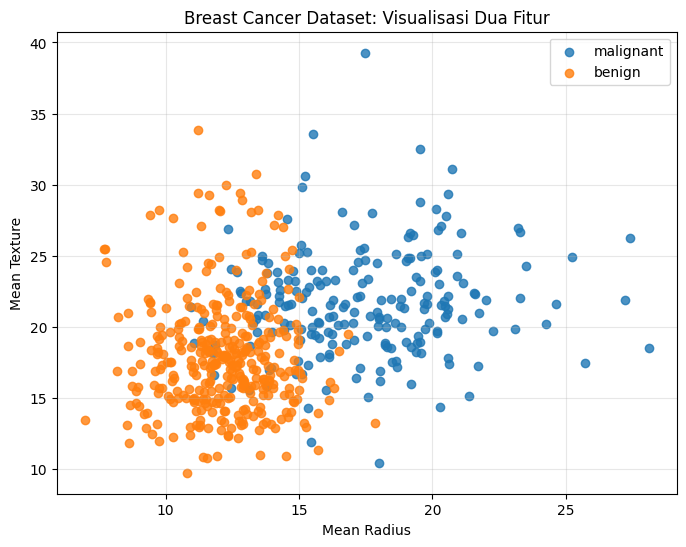

In [ ]:
plt.figure(figsize=(8, 6))

for class_id, class_name in enumerate(breast_cancer.target_names):

    subset = bc_df[bc_df["diagnosis_code"] == class_id]

    plt.scatter(
        subset["mean radius"],
        subset["mean texture"],
        label=class_name,
        alpha=0.8
    )

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")

plt.title("Breast Cancer Dataset: Visualisasi Dua Fitur")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## C.2 Train-Test Split

Dalam statistical learning, data biasanya dibagi menjadi:

- **training set**: digunakan untuk melatih model;
- **testing set**: digunakan untuk mengevaluasi model pada data yang belum pernah dilihat.

Tujuan utama pembagian ini adalah mengukur kemampuan model melakukan **generalization**.

In [ ]:
X_train_clas, X_test_clas, y_train_clas, y_test_clas = train_test_split(
    X_bc,
    y_bc,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_bc
)

print("Ukuran X_train:", X_train_clas.shape)
print("Ukuran X_test :", X_test_clas.shape)

print("Ukuran y_train:", y_train_clas.shape)
print("Ukuran y_test :", y_test_clas.shape)

Ukuran X_train: (426, 30)
Ukuran X_test : (143, 30)
Ukuran y_train: (426,)
Ukuran y_test : (143,)


## C.3 Model Classification Sederhana: Decision Tree

Decision Tree digunakan di sini karena mudah divisualisasikan. Model ini bekerja dengan membuat aturan split seperti:

> Jika `mean radius <= nilai tertentu`, maka data masuk ke cabang kiri; jika tidak, masuk ke cabang kanan.

In [ ]:
tree_clf = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)

tree_clf.fit(X_train_clas, y_train_clas)

# Prediction
y_train_pred = tree_clf.predict(X_train_clas)
y_test_pred = tree_clf.predict(X_test_clas)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# Train-test gap
gap = train_acc - test_acc

print(f"Training accuracy : {train_acc:.3f}")
print(f"Testing accuracy  : {test_acc:.3f}")
print(f"Train-test gap    : {gap:.3f}")

print("\nTree depth        :", tree_clf.get_depth())
print("Number of leaves  :", tree_clf.get_n_leaves())

Training accuracy : 0.977
Testing accuracy  : 0.944
Train-test gap    : 0.032

Tree depth        : 3
Number of leaves  : 7


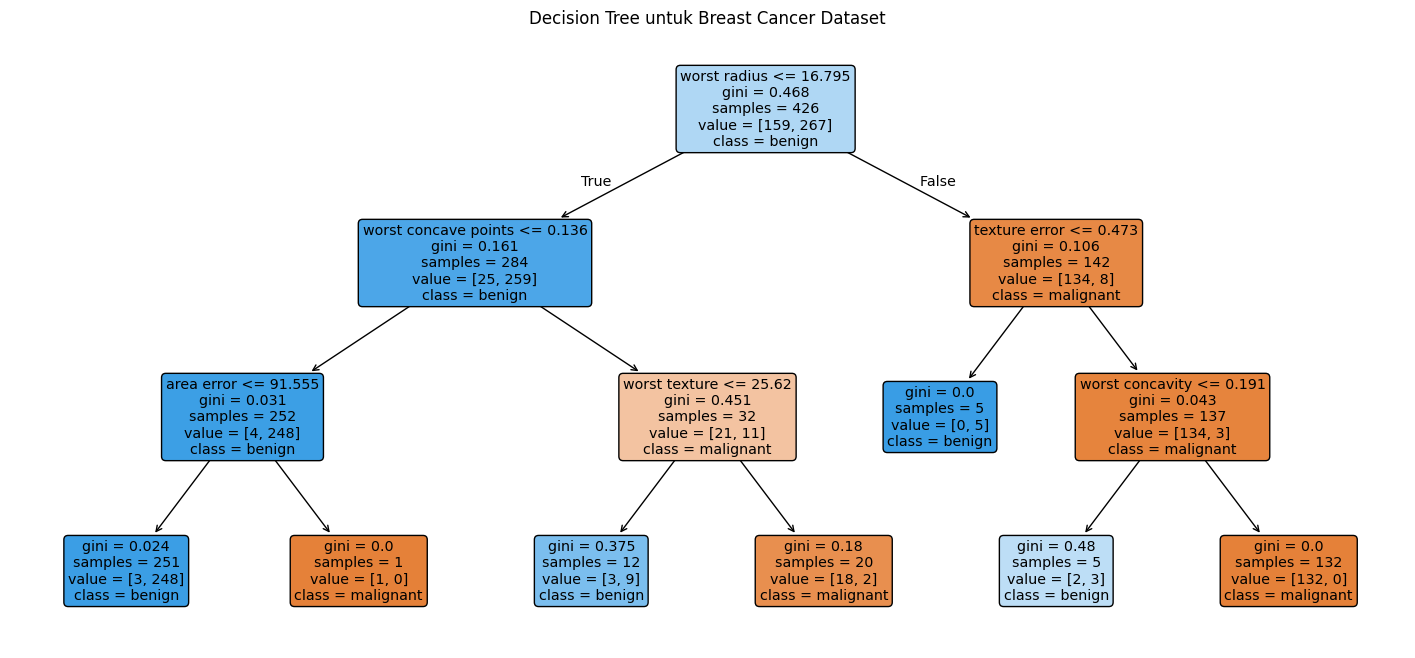

In [ ]:
plt.figure(figsize=(18, 8))

plot_tree(
    tree_clf,
    feature_names=breast_cancer.feature_names,
    class_names=breast_cancer.target_names,
    filled=True,
    rounded=True
)

plt.title("Decision Tree untuk Breast Cancer Dataset")

plt.show()

## C.4 Interpretasi

Perhatikan bahwa tree yang dangkal biasanya mudah diinterpretasikan. Namun, model yang terlalu sederhana dapat gagal menangkap pola penting dalam data. Kondisi ini disebut **underfitting**.

Sebaliknya, tree yang terlalu dalam dapat menyesuaikan diri secara berlebihan terhadap data training. Kondisi ini disebut **overfitting**.

# Bagian D — Supervised Learning: Regression dengan Dataset Diabetes

Sekarang kita masuk ke contoh supervised learning dengan target numerik. Dataset `diabetes` berisi beberapa variabel klinis, dan targetnya adalah ukuran perkembangan penyakit diabetes.

Karena targetnya numerik, ini adalah contoh **regression**.

In [ ]:

diabetes = load_diabetes()

X_diabetes = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

y_diabetes = pd.Series(
    diabetes.target,
    name="disease_progression"
)

diabetes_df = X_diabetes.copy()
diabetes_df["disease_progression"] = y_diabetes

diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
print("Ukuran dataset:", diabetes_df.shape)

print("\nNama fitur:")
print(diabetes.feature_names)

print("\nRingkasan target:")
print(diabetes_df["disease_progression"].describe())

Ukuran dataset: (442, 11)

Nama fitur:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Ringkasan target:
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: disease_progression, dtype: float64


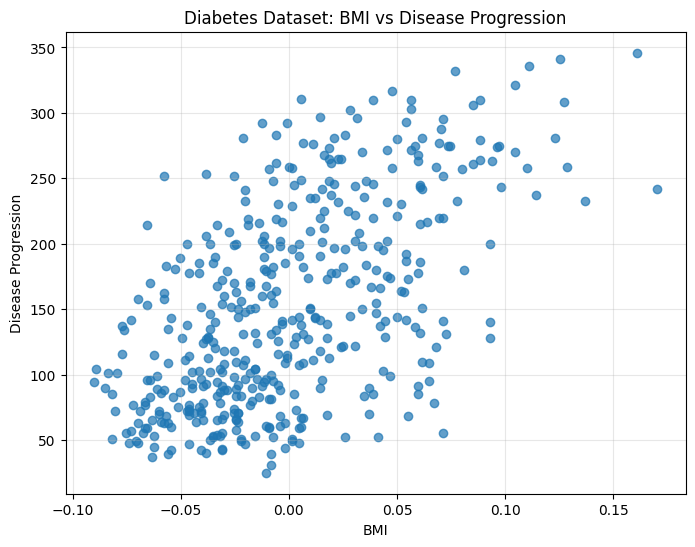

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    diabetes_df["bmi"],
    diabetes_df["disease_progression"],
    alpha=0.7
)

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Diabetes Dataset: BMI vs Disease Progression")
plt.grid(True, alpha=0.3)

plt.show()

## D.1 Train-Test Split untuk Regression

In [ ]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print("Ukuran X_train:", X_train_reg.shape)
print("Ukuran X_test :", X_test_reg.shape)
print("Ukuran y_train:", y_train_reg.shape)
print("Ukuran y_test :", y_test_reg.shape)

Ukuran X_train: (331, 10)
Ukuran X_test : (111, 10)
Ukuran y_train: (331,)
Ukuran y_test : (111,)


In [ ]:
tree_reg = DecisionTreeRegressor(
    max_depth=2,
    random_state=RANDOM_STATE
)

tree_reg.fit(X_train_reg, y_train_reg)

y_train_pred = tree_reg.predict(X_train_reg)
y_test_pred = tree_reg.predict(X_test_reg)

train_mse = mean_squared_error(y_train_reg, y_train_pred)
test_mse = mean_squared_error(y_test_reg, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train_reg, y_train_pred)
test_r2 = r2_score(y_test_reg, y_test_pred)

print(f"Training RMSE: {train_rmse:.3f}")
print(f"Testing RMSE : {test_rmse:.3f}")

print(f"Training R²  : {train_r2:.3f}")
print(f"Testing R²   : {test_r2:.3f}")

print("\nTree depth       :", tree_reg.get_depth())
print("Number of leaves :", tree_reg.get_n_leaves())

Training RMSE: 58.282
Testing RMSE : 59.546
Training R²  : 0.438
Testing R²   : 0.359

Tree depth       : 2
Number of leaves : 4


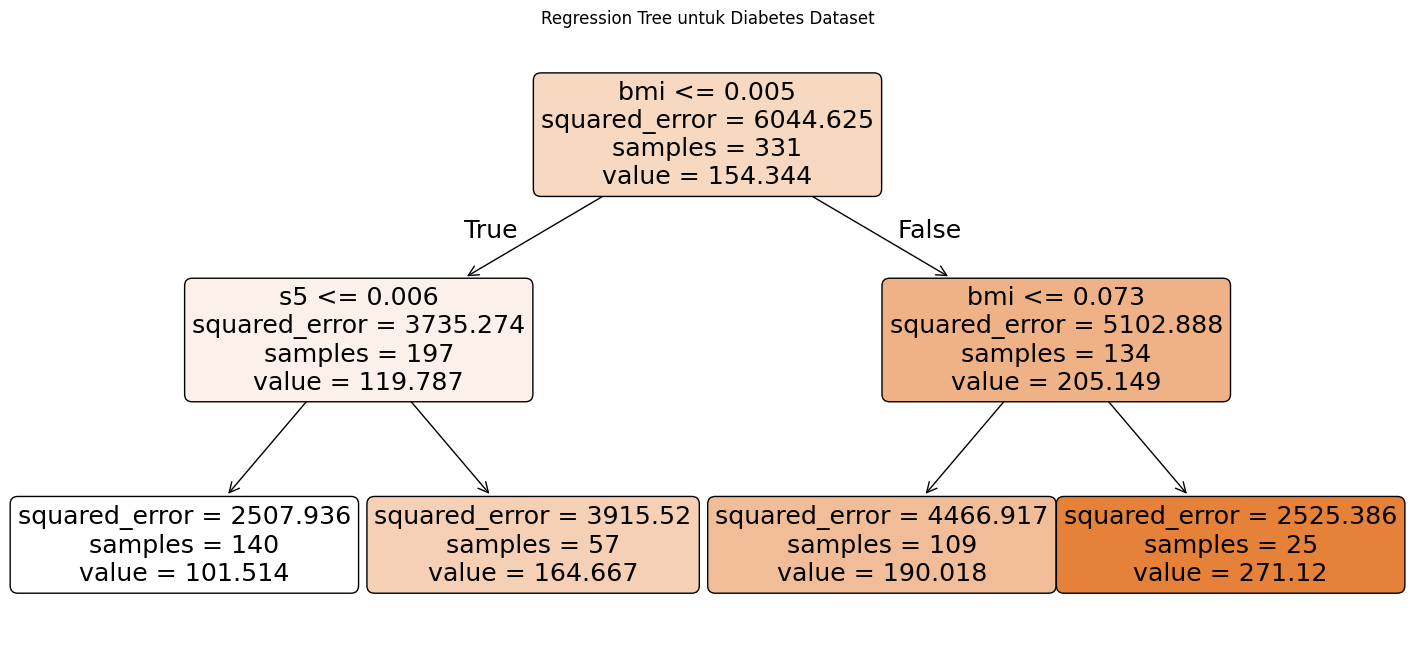

In [ ]:
plt.figure(figsize=(18, 8))

plot_tree(
    tree_reg,
    feature_names=diabetes.feature_names,
    filled=True,
    rounded=True
)

plt.title("Regression Tree untuk Diabetes Dataset")

plt.show()

## D.2 Linear Regression sebagai Model Dasar

Linear regression memodelkan hubungan linear:

$$
\hat{Y} = \beta_0 + \beta_1X_1 + \beta_2X_2 + \cdots + \beta_pX_p.
$$

Model ini relatif sederhana, sehingga cenderung memiliki variance rendah. Namun, jika hubungan sebenarnya tidak linear, model dapat memiliki bias tinggi.

In [ ]:
lin_reg = LinearRegression()

lin_reg.fit(X_train_reg, y_train_reg)

# Prediction
pred_train_lin = lin_reg.predict(X_train_reg)
pred_test_lin = lin_reg.predict(X_test_reg)

# Evaluation metrics
rmse_train_lin = np.sqrt(
    mean_squared_error(y_train_reg, pred_train_lin)
)

rmse_test_lin = np.sqrt(
    mean_squared_error(y_test_reg, pred_test_lin)
)

r2_train_lin = r2_score(
    y_train_reg,
    pred_train_lin
)

r2_test_lin = r2_score(
    y_test_reg,
    pred_test_lin
)

print(f"Training RMSE: {rmse_train_lin:.2f}")
print(f"Testing RMSE : {rmse_test_lin:.2f}")

print(f"Training R²  : {r2_train_lin:.3f}")
print(f"Testing R²   : {r2_test_lin:.3f}")

Training RMSE: 53.92
Testing RMSE : 53.37
Training R²  : 0.519
Testing R²   : 0.485


# Bagian E — Generalization: Training Error vs Testing Error

Model yang baik bukan model yang hanya bagus pada data training, tetapi model yang tetap baik pada data testing.

Jika performa training sangat tinggi tetapi performa testing rendah, maka model kemungkinan mengalami **overfitting**.

Jika performa training dan testing sama-sama rendah, maka model kemungkinan mengalami **underfitting**.

## E.1 Pengaruh Kompleksitas Tree pada Classification

Kita akan membandingkan beberapa nilai `max_depth`. Semakin besar `max_depth`, semakin kompleks tree yang terbentuk.

In [ ]:
depths = range(1, 11)
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    model.fit(X_train_clas, y_train_clas)
    train_scores.append(accuracy_score(y_train_clas, model.predict(X_train_clas)))
    test_scores.append(accuracy_score(y_test_clas, model.predict(X_test_clas)))

result_depth = pd.DataFrame({
    "max_depth": list(depths),
    "training_accuracy": train_scores,
    "testing_accuracy": test_scores
})

result_depth

,max_depth,training_accuracy,testing_accuracy
0,1,0.922535,0.923077
1,2,0.957746,0.909091
2,3,0.976526,0.944056
3,4,0.988263,0.944056
4,5,0.995305,0.937063
5,6,0.997653,0.937063
6,7,1.000000,0.923077
7,8,1.000000,0.923077
8,9,1.000000,0.923077
9,10,1.000000,0.923077


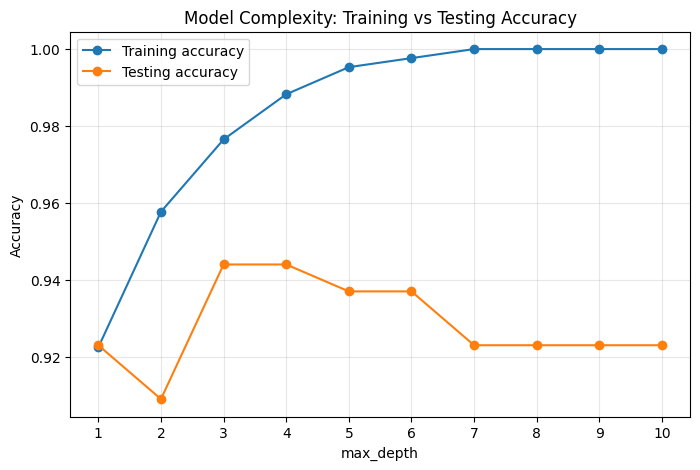

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(result_depth["max_depth"], result_depth["training_accuracy"], marker="o", label="Training accuracy")
plt.plot(result_depth["max_depth"], result_depth["testing_accuracy"], marker="o", label="Testing accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Model Complexity: Training vs Testing Accuracy")
plt.xticks(list(depths))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## E.2 Interpretasi Grafik

Secara umum:

- Ketika tree sangat dangkal, model terlalu sederhana dan dapat mengalami **underfitting**.
- Ketika tree semakin dalam, training accuracy biasanya meningkat.
- Namun, testing accuracy tidak selalu meningkat. Jika testing accuracy menurun ketika training accuracy tetap tinggi, indikasinya adalah **overfitting**.

Inilah alasan mengapa evaluasi pada testing data sangat penting.

## E.3 Pengaruh Kompleksitas Tree pada Regression

Kita akan membandingkan beberapa nilai `max_depth`. Semakin besar `max_depth`, semakin kompleks tree yang terbentuk.

In [ ]:
depths = range(1, 11)

train_rmse_scores = []
test_rmse_scores = []
train_r2_scores = []
test_r2_scores = []

for d in depths:
    model = DecisionTreeRegressor(
        max_depth=d,
        random_state=RANDOM_STATE
    )

    model.fit(X_train_reg, y_train_reg)

    y_train_pred = model.predict(X_train_reg)
    y_test_pred = model.predict(X_test_reg)

    train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred))

    train_r2 = r2_score(y_train_reg, y_train_pred)
    test_r2 = r2_score(y_test_reg, y_test_pred)

    train_rmse_scores.append(train_rmse)
    test_rmse_scores.append(test_rmse)
    train_r2_scores.append(train_r2)
    test_r2_scores.append(test_r2)

result_depth_reg = pd.DataFrame({
    "max_depth": list(depths),
    "training_RMSE": train_rmse_scores,
    "testing_RMSE": test_rmse_scores,
    "training_R2": train_r2_scores,
    "testing_R2": test_r2_scores
})

result_depth_reg

,max_depth,training_RMSE,testing_RMSE,training_R2,testing_R2
0,1,65.489928,65.888622,0.290455,0.214909
1,2,58.281644,59.546276,0.438054,0.358778
2,3,54.450647,59.258488,0.509503,0.364961
3,4,50.222610,59.651587,0.582718,0.356508
4,5,43.518098,62.981947,0.686693,0.282650
5,6,37.446789,66.743483,0.768015,0.194405
6,7,31.540192,74.151866,0.835427,0.005641
7,8,26.078885,71.688429,0.887485,0.070611
8,9,20.451482,73.757074,0.930804,0.016201
9,10,15.670593,70.787328,0.959374,0.093829


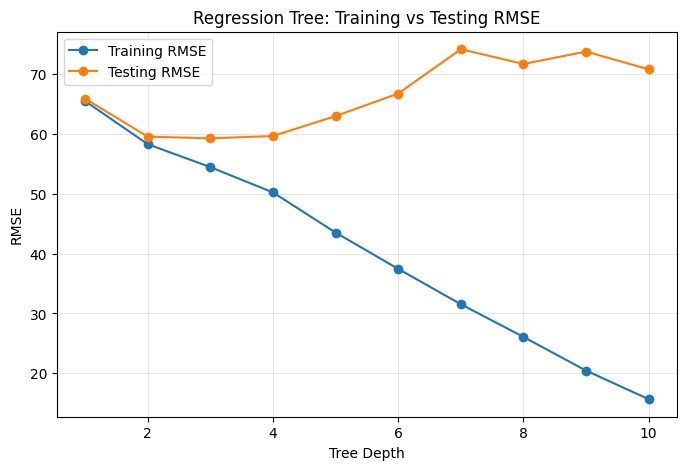

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    result_depth_reg["max_depth"],
    result_depth_reg["training_RMSE"],
    marker="o",
    label="Training RMSE"
)

plt.plot(
    result_depth_reg["max_depth"],
    result_depth_reg["testing_RMSE"],
    marker="o",
    label="Testing RMSE"
)

plt.xlabel("Tree Depth")
plt.ylabel("RMSE")

plt.title("Regression Tree: Training vs Testing RMSE")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# Bagian F — Bias–Variance Tradeoff

## F.1 Ide Dasar

Dalam supervised learning, error prediksi dapat dipahami melalui tiga komponen utama:

$$
\text{Expected Test Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}.
$$

Maknanya:

| Komponen | Makna | Ciri |
|---|---|---|
| Bias | Kesalahan karena model terlalu sederhana | Underfitting |
| Variance | Sensitivitas model terhadap perubahan data training | Overfitting |
| Irreducible Error | Noise alami yang tidak dapat dihilangkan | Tetap ada meskipun model baik |

Model sederhana cenderung memiliki **bias tinggi** dan **variance rendah**.  
Model kompleks cenderung memiliki **bias rendah** dan **variance tinggi**.

## F.2 Simulasi Bias–Variance dengan Polynomial Regression

Kita akan membuat data sintetis dari fungsi non-linear:

$$
y = \sin(2\pi x) + \varepsilon.
$$

Kemudian kita bandingkan model polynomial dengan derajat berbeda:

- degree 1: terlalu sederhana,
- degree 3 atau 5: cukup fleksibel,
- degree 15: terlalu kompleks.

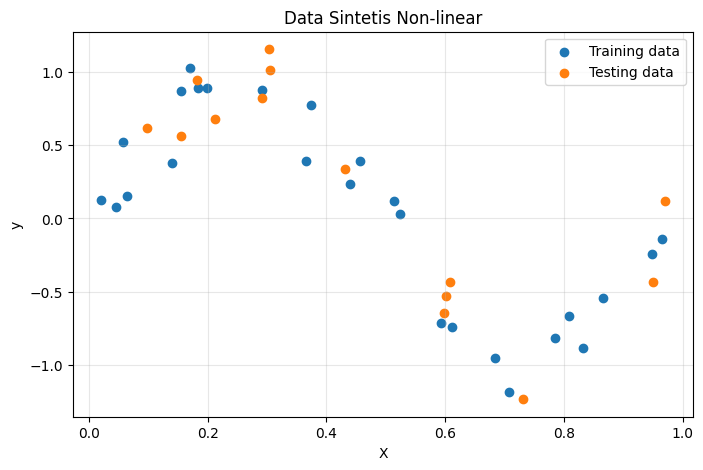

In [ ]:
# Membuat data sintetis
n_samples = 40
X_sim = np.sort(np.random.rand(n_samples))
y_sim = np.sin(2 * np.pi * X_sim) + np.random.normal(0, 0.2, size=n_samples)

X_sim = X_sim.reshape(-1, 1)

X_train_sim, X_test_sim, y_train_sim, y_test_sim = train_test_split(
    X_sim,
    y_sim,
    test_size=0.35,
    random_state=RANDOM_STATE
)

plt.figure(figsize=(8, 5))
plt.scatter(X_train_sim, y_train_sim, label="Training data")
plt.scatter(X_test_sim, y_test_sim, label="Testing data")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Data Sintetis Non-linear")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

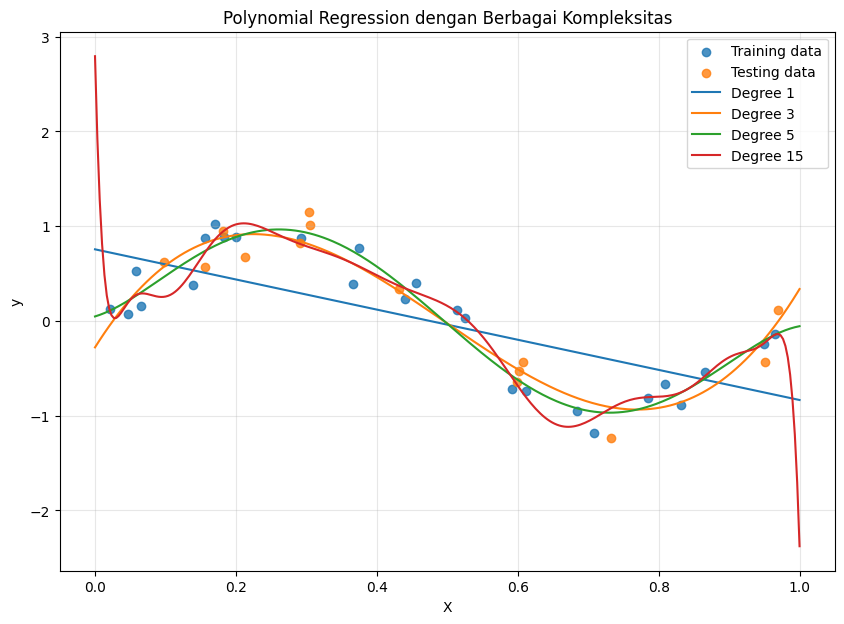

In [ ]:
degrees = [1, 3, 5, 15]
x_grid = np.linspace(0, 1, 300).reshape(-1, 1)

plt.figure(figsize=(10, 7))
plt.scatter(X_train_sim, y_train_sim, label="Training data", alpha=0.8)
plt.scatter(X_test_sim, y_test_sim, label="Testing data", alpha=0.8)

for deg in degrees:
    poly_model = Pipeline([
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("linreg", LinearRegression())
    ])
    poly_model.fit(X_train_sim, y_train_sim)
    y_grid_pred = poly_model.predict(x_grid)
    plt.plot(x_grid, y_grid_pred, label=f"Degree {deg}")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression dengan Berbagai Kompleksitas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
poly_results = []

for deg in range(1, 21):
    poly_model = Pipeline([
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("linreg", LinearRegression())
    ])
    poly_model.fit(X_train_sim, y_train_sim)

    train_rmse = np.sqrt(mean_squared_error(y_train_sim, poly_model.predict(X_train_sim)))
    test_rmse = np.sqrt(mean_squared_error(y_test_sim, poly_model.predict(X_test_sim)))

    poly_results.append({
        "degree": deg,
        "training_RMSE": train_rmse,
        "testing_RMSE": test_rmse
    })

poly_results_df = pd.DataFrame(poly_results)
poly_results_df.head(10)

,degree,training_RMSE,testing_RMSE
0,1,0.451441,0.530329
1,2,0.450086,0.539014
2,3,0.182037,0.189354
3,4,0.181891,0.187836
4,5,0.160208,0.179177
5,6,0.157179,0.183143
6,7,0.154927,0.192883
7,8,0.144984,0.190956
8,9,0.142689,0.171348
9,10,0.130592,0.223802


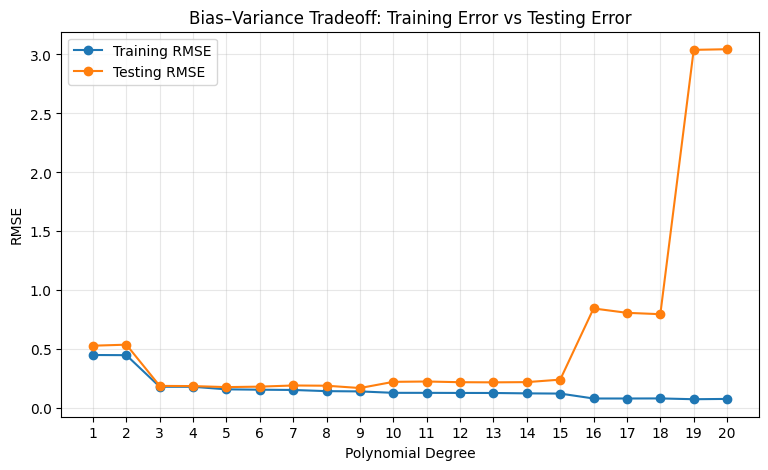

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(poly_results_df["degree"], poly_results_df["training_RMSE"], marker="o", label="Training RMSE")
plt.plot(poly_results_df["degree"], poly_results_df["testing_RMSE"], marker="o", label="Testing RMSE")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Bias–Variance Tradeoff: Training Error vs Testing Error")
plt.xticks(range(1, 21))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## F.3 Interpretasi Bias–Variance

Dari grafik di atas, biasanya terlihat pola berikut:

1. **Degree rendah**  
   Model terlalu sederhana, sehingga tidak mampu menangkap pola non-linear. Ini mengarah pada **high bias**.

2. **Degree sedang**  
   Model cukup fleksibel untuk menangkap pola utama. Ini biasanya menghasilkan performa testing yang lebih baik.

3. **Degree terlalu tinggi**  
   Model terlalu mengikuti data training, termasuk noise. Ini mengarah pada **high variance**.

Kesimpulan penting:

> Tujuan kita bukan mencari model yang paling sempurna pada data training, tetapi model yang paling mampu melakukan generalisasi pada data baru.

# Bagian G — Cross Validation

Train-test split hanya membagi data satu kali. Hasil evaluasi dapat bergantung pada bagaimana data dibagi.

**Cross validation** membantu mengevaluasi model secara lebih stabil dengan membagi data menjadi beberapa fold.

Pada pertemuan ini, cross validation hanya diperkenalkan sebagai alat untuk memahami generalization. Pembahasan evaluasi classification yang lebih lengkap akan dilakukan pada Pertemuan 13.

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for d in range(1, 11):
    model = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_iris, y_iris, cv=cv, scoring="accuracy")
    cv_results.append({
        "max_depth": d,
        "mean_cv_accuracy": scores.mean(),
        "std_cv_accuracy": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,max_depth,mean_cv_accuracy,std_cv_accuracy
0,1,0.633333,0.029814
1,2,0.946667,0.016330
2,3,0.953333,0.033993
3,4,0.953333,0.026667
4,5,0.953333,0.026667
5,6,0.953333,0.026667
6,7,0.953333,0.026667
7,8,0.953333,0.026667
8,9,0.953333,0.026667
9,10,0.953333,0.026667


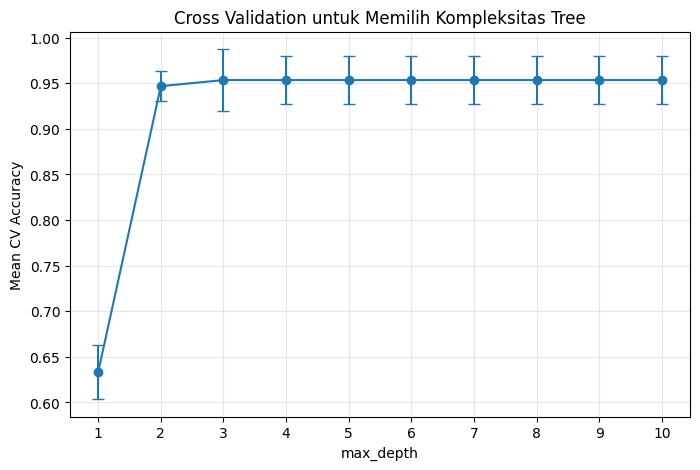

In [ ]:
plt.figure(figsize=(8, 5))
plt.errorbar(
    cv_results_df["max_depth"],
    cv_results_df["mean_cv_accuracy"],
    yerr=cv_results_df["std_cv_accuracy"],
    marker="o",
    capsize=4
)
plt.xlabel("max_depth")
plt.ylabel("Mean CV Accuracy")
plt.title("Cross Validation untuk Memilih Kompleksitas Tree")
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.show()

# Bagian H — Unsupervised Learning: Pengantar Clustering

Pada unsupervised learning, kita tidak memiliki target. Untuk memperkenalkan konsep ini, kita gunakan data sintetis yang terdiri dari beberapa kelompok.

Catatan: K-Means akan dibahas lebih lengkap pada Pertemuan 14. Di sini, fokusnya hanya membedakan supervised dan unsupervised learning.

In [ ]:
X_blob, true_group = make_blobs(
    n_samples=250,
    centers=3,
    cluster_std=1.2,
    random_state=RANDOM_STATE
)

blob_df = pd.DataFrame(X_blob, columns=["feature_1", "feature_2"])
blob_df.head()

,feature_1,feature_2
0,-1.410715,9.408787
1,4.057443,2.071419
2,5.939540,3.237732
3,-1.353146,9.509623
4,-7.957725,-6.289807


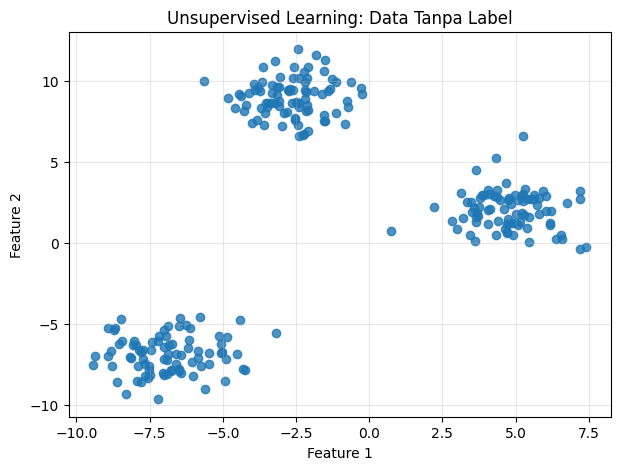

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(blob_df["feature_1"], blob_df["feature_2"], alpha=0.8)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Unsupervised Learning: Data Tanpa Label")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
kmeans_intro = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
cluster_label = kmeans_intro.fit_predict(blob_df)

blob_df["cluster"] = cluster_label
blob_df.head()

,feature_1,feature_2,cluster
0,-1.410715,9.408787,0
1,4.057443,2.071419,2
2,5.939540,3.237732,2
3,-1.353146,9.509623,0
4,-7.957725,-6.289807,1


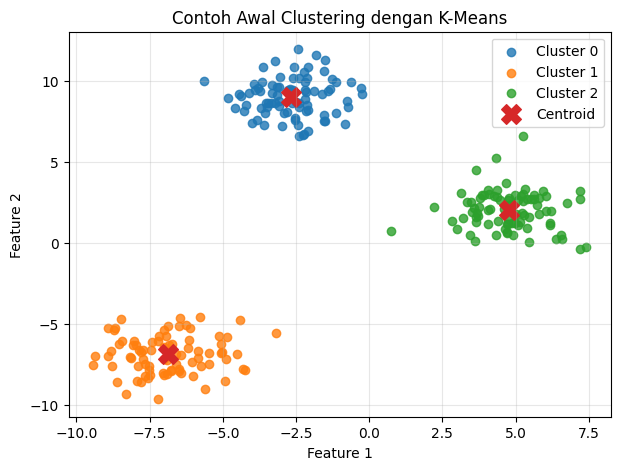

In [ ]:
plt.figure(figsize=(7, 5))
for cl in sorted(blob_df["cluster"].unique()):
    subset = blob_df[blob_df["cluster"] == cl]
    plt.scatter(subset["feature_1"], subset["feature_2"], label=f"Cluster {cl}", alpha=0.8)

plt.scatter(
    kmeans_intro.cluster_centers_[:, 0],
    kmeans_intro.cluster_centers_[:, 1],
    marker="X",
    s=200,
    label="Centroid"
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Contoh Awal Clustering dengan K-Means")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## H.1 Interpretasi

Pada clustering:

- model tidak diberi label benar/salah;
- model mencari kelompok berdasarkan kemiripan fitur;
- hasil cluster perlu diinterpretasikan secara substantif.

Perbedaan penting:

| Supervised Learning | Unsupervised Learning |
|---|---|
| Ada target $Y$ | Tidak ada target $Y$ |
| Tujuan: prediksi/inferensi | Tujuan: menemukan struktur |
| Contoh: classification, regression | Contoh: clustering, PCA |
| Evaluasi lebih langsung | Evaluasi lebih eksploratif |

# Bagian I — Dimensionality Reduction Singkat dengan PCA

Selain clustering, unsupervised learning juga mencakup **dimensionality reduction**. Salah satu metode klasik adalah PCA.

PCA bertujuan merangkum banyak fitur menjadi beberapa komponen utama yang menangkap variasi terbesar dalam data.

In [ ]:
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["species_name"] = iris_df["species_name"]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.72962445 0.22850762]
Total explained variance: 0.9581320720000164


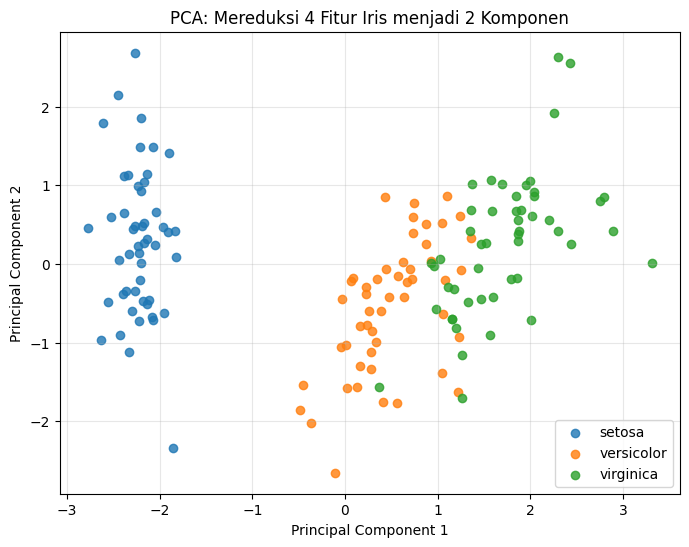

In [ ]:
plt.figure(figsize=(8, 6))
for species in iris.target_names:
    subset = pca_df[pca_df["species_name"] == species]
    plt.scatter(subset["PC1"], subset["PC2"], label=species, alpha=0.8)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: Mereduksi 4 Fitur Iris menjadi 2 Komponen")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Bagian K — Latihan Mandiri

Kerjakan latihan berikut untuk memperkuat pemahaman.

## Latihan 1
Gunakan dataset `Iris`. Bangun Decision Tree dengan `max_depth = 1, 2, 3, 4, 5`. Bandingkan training accuracy dan testing accuracy.

## Latihan 2
Pada simulasi polynomial regression, ubah jumlah data dari `n_samples = 40` menjadi `n_samples = 100`. Apakah pola overfitting berubah?

## Latihan 3
Gunakan dataset `Diabetes`. Bandingkan model:

1. Linear Regression;
2. DecisionTreeRegressor dengan `max_depth = 2`;
3. DecisionTreeRegressor dengan `max_depth = 10`.

Bandingkan RMSE training dan testing.

## Latihan 4
Gunakan data clustering sintetis. Ubah `n_clusters` pada KMeans menjadi 2, 3, 4, dan 5. Apa yang terjadi pada hasil cluster?

## Latihan 5
Jelaskan dengan bahasa sendiri:

1. Apa perbedaan supervised dan unsupervised learning?
2. Apa perbedaan regression dan classification?
3. Apa yang dimaksud dengan bias?
4. Apa yang dimaksud dengan variance?
5. Mengapa testing error lebih penting daripada training error?

# TUGAS

Kerjakan latihan berikut untuk memperkuat pemahaman.

## Data Set
Gunakan dataset dengan ketentuan berikut:
1. memiliki variabel prediktor (features/input),
2. memiliki variabel target variable/output.
3. Memiliki minimal 100 observasi dan 3 variabel prediktor.
4. Data dapat berupa numerik, kategorik, atau kombinasi keduanya.

## Part A — Data Exploration
1. Lakukan eksplorasi awal terhadap dataset dan Buat statistik deskriptif sederhana.
2. Jelasan apakah dataset termasuk supervised learning,dan apa target variable pada dataset tersebut.

## Part B — Train-Test Split
Pisahkan data menjadi 70% training data dan 30% testing data

Pertanyaan:
1. Apa fungsi training data?
2. Apa fungsi testing data?
3. Mengapa model tidak boleh dievaluasi menggunakan training data saja?

## Part C — Decision Tree Modeling
Bangun beberapa model Decision Tree dengan tingkat kompleksitas berbeda.

Gunakan:

`max_depth = 1`

`max_depth = 2`

`max_depth = 3`

`max_depth = 5`

`max_depth = None`

Kemudian hitung `training accuracy`, `testing accuracy`. Bandingkan seluruh model dan Buat tabel hasil perbandingan.


## Part D — Underfitting vs Overfitting
Analisis hasil model yang telah dibuat dengan menjawab pertanyaan-pertanyaan berikut:
1. Model mana yang mengalami underfitting?
2. Model mana yang mengalami overfitting?
3. Mengapa model terlalu kompleks dapat menyebabkan overfitting?
4. Apa dampak overfitting terhadap generalization?

## Part E — Bias–Variance Tradeoff
1. Buat grafik yang membandingkan training accuracy dengan testing accuracy.
2. Apa hubungan antara kompleksitas model dan variance?
3. Apa hubungan antara kompleksitas model dan bias?
4. Mengapa diperlukan keseimbangan antara bias dan variance?

##Part F — Visualization
Visualisasikan Decision Tree terbaik. Kemudian jawab pertanyaan-pertanyaan berikut:
1. Interpretasikan struktur tree
2. Fitur apa yang paling penting?


Pertemuan berikutnya akan masuk lebih dalam pada:

- **Logistic Regression** untuk classification;
- **Confusion Matrix, Accuracy, Precision, Recall, F1-score**;
- **K-Means Clustering**;
- **Evaluation Metrics** untuk classification dan clustering.